In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

In [1]:
import pandas as pd

from energymanagementrl.production_forecast import PanelModel, ArrayConfig, PlantConfig, WeatherType, \
    analyze_production, EnergyPredictionSystem, OpenMeteoClient

In [ ]:
open_meteo_client = OpenMeteoClient()

In [3]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
num_panels = 14
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=num_panels, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=num_panels, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)
energy_prediction_system = EnergyPredictionSystem(plant_config=plant_config, open_meteo_client=open_meteo_client)

Total AC energy: 82.18 kWh
Max production: 4.77 kW at 2024-12-18 10:45:00
Production starts at: 2024-12-18 06:20:00, ends at: 2024-12-18 15:40:00


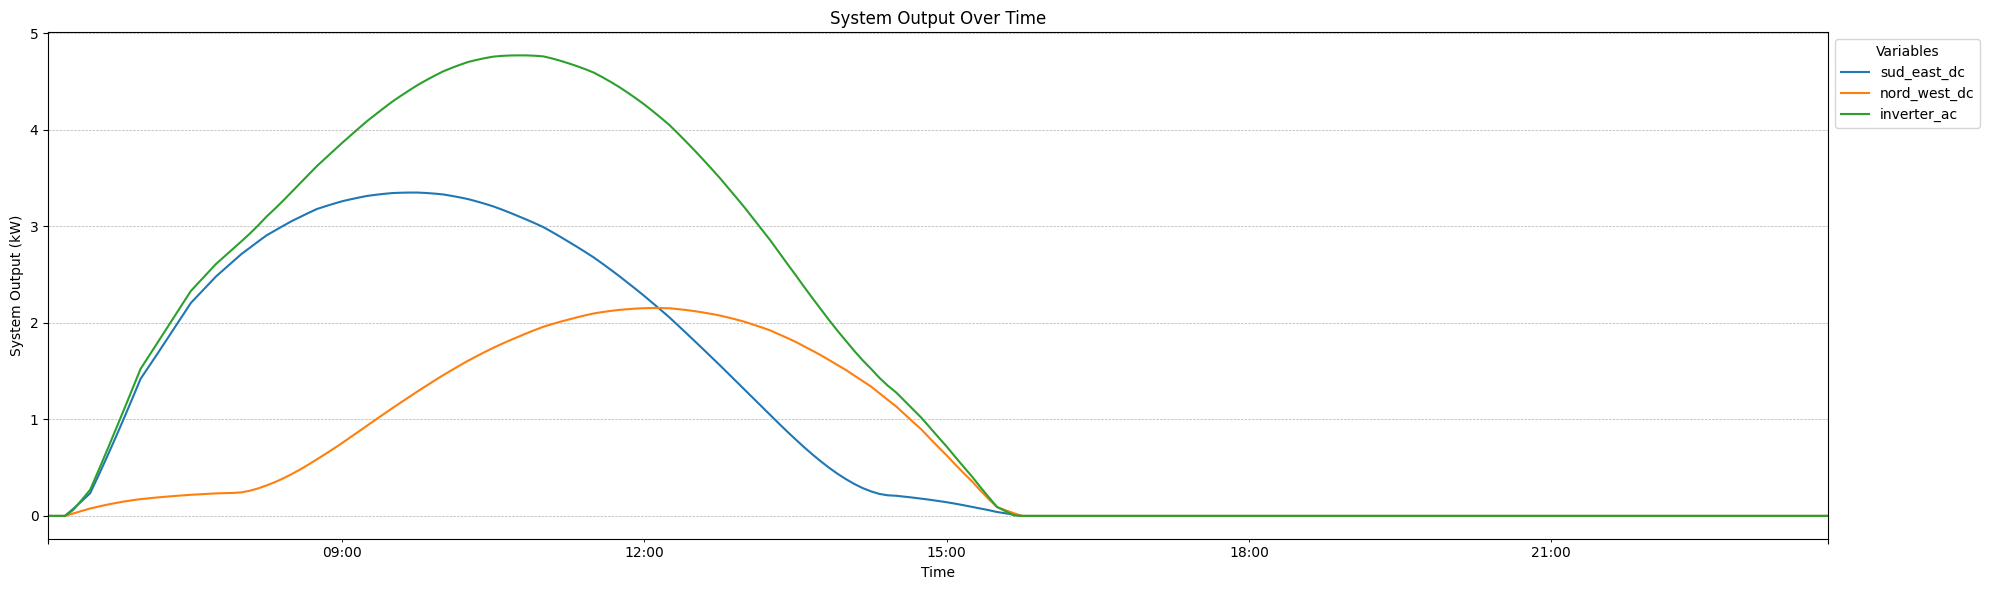

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 213 entries, 2024-12-18 06:05:00 to 2024-12-18 23:45:00
Freq: 5min
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sud_east_dc   213 non-null    float64
 1   nord_west_dc  213 non-null    float64
 2   inverter_ac   213 non-null    float64
dtypes: float64(3)
memory usage: 6.7 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 215 entries, 2024-12-18 06:05:00 to 2024-12-18 23:55:00
Freq: 5min
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sud_east_dc   215 non-null    float64
 1   nord_west_dc  215 non-null    float64
 2   inverter_ac   215 non-null    float64
dtypes: float64(3)
memory usage: 6.7 KB


In [13]:
open_meteo_production_df = energy_prediction_system.run_energy_production_prediction(
    '2024-12-18 06:05',
    '2024-12-18 23:55',
    WeatherType.open_meteo
)
analyze_production(open_meteo_production_df)
open_meteo_production_df.info()
#
clear_sky_production_df = energy_prediction_system.run_energy_production_prediction(
    '2024-12-18 06:05',
    '2024-12-18 23:55',
    WeatherType.clear_sky
)
clear_sky_production_df.info()

<Axes: >

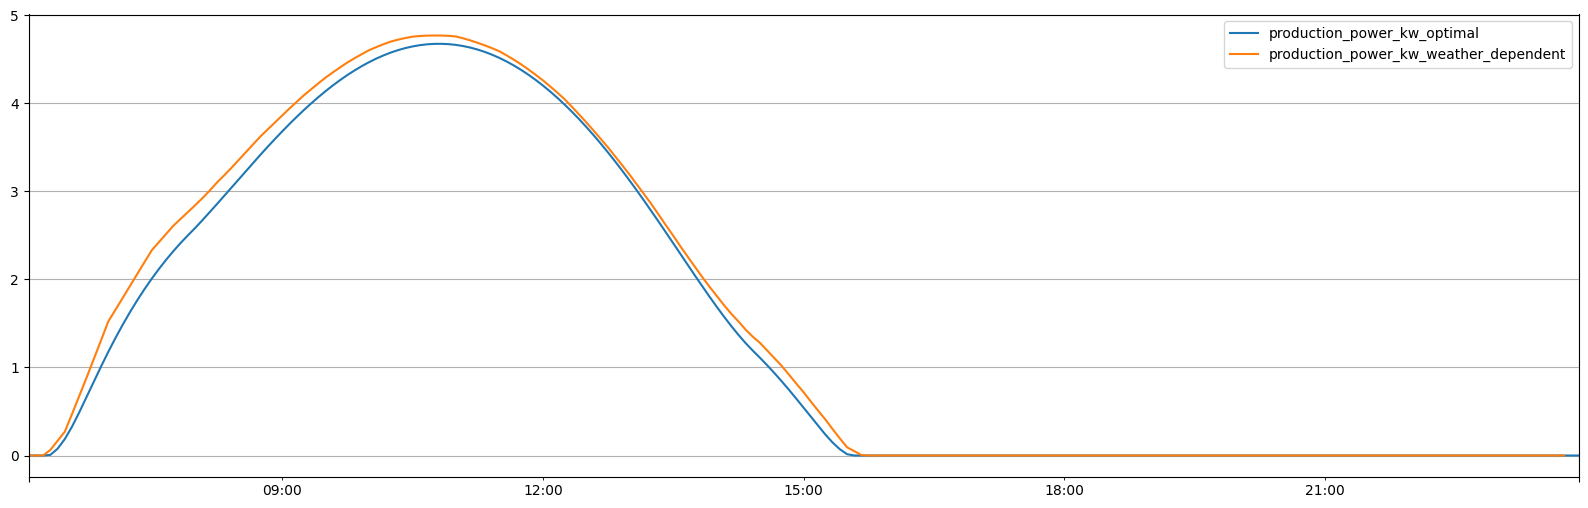

In [12]:
clear_sky_production_df.rename({'inverter_ac': 'production_power_kw_optimal'}, axis=1, inplace=True)
open_meteo_production_df.rename({'inverter_ac': 'production_power_kw_weather_dependent'}, axis=1, inplace=True)
merged_df = pd.concat([clear_sky_production_df.production_power_kw_optimal,
                  open_meteo_production_df.production_power_kw_weather_dependent], axis=1)
merged_df.plot(figsize=(20, 6), grid=True)
